# Step 1 — Import Dependencies

In [42]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Step 2 — Load Dataset

In [43]:
df = pd.read_csv("/content/CLEANED_marketing_campaign_dataset.csv")



In [44]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200000, 28)


,campaign_id,company,campaign_type,target_audience,duration,channels_used,conversion_rate,acquisition_cost,roi,location,language,clicks,impressions,engagement_score,customer_segment,campaign_date,gender,age_group,aov,seasonal_boost,channel_multiplier,ctr,conversion_volume,calculated_revenue,total_revenue,total_profit,roi_ratio,cpa
0,881,Techcorp,Search,Men 25-34,15,Google Ads,0.01,"7,866.00",5.42,Miami,English,576,5231,3.00,Fashionistas,2021-05-31,Men,25-34,800.00,1.00,1.25,0.11,5.76,"5,501.66","5,501.66","-2,364.34",-0.30,"1,365.63"
1,1682,Techcorp,Display,Men 25-34,30,Email,0.09,"16,794.00",2.43,Chicago,German,873,2646,10.00,Fashionistas,2021-08-10,Men,25-34,800.00,1.00,1.10,0.33,78.57,"65,778.28","65,778.28","48,984.28",2.92,213.75
2,2048,Innovate Industries,Search,Men 25-34,60,Email,0.03,"16,537.00",3.76,Los Angeles,French,382,3692,2.00,Fashionistas,2021-08-11,Men,25-34,800.00,1.00,1.10,0.10,11.46,"9,595.01","9,595.01","-6,941.99",-0.42,"1,443.02"
3,2160,Techcorp,Display,Men 25-34,60,Website,0.14,"15,594.00",2.15,New York,Spanish,446,7057,4.00,Foodies,2021-12-01,Men,25-34,600.00,1.15,0.90,0.06,62.44,"36,903.43","36,903.43","21,309.43",1.37,249.74
4,2223,Nexgen Systems,Social Media,Men 25-34,45,Website,0.05,"16,567.00",4.66,New York,Spanish,224,9023,1.00,Outdoor Adventurers,2021-02-02,Men,25-34,"1,000.00",1.00,0.90,0.02,11.20,"9,590.36","9,590.36","-6,976.64",-0.42,"1,479.20"


# Step 3 — Validate Required Columns

In [45]:
required_columns = [
    "channels_used",
    "customer_segment",
    "acquisition_cost",
    "roi_ratio",
    "total_profit"
]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

print("All required columns are present.")

All required columns are present.


# Step 4 — Create Scenario Budget Column

In [47]:
df["optimized_spend"] = df["acquisition_cost"]

# Step 5 — Apply Scenario Rules

In [48]:
# 5.1 Reduce Email Budget
df.loc[
    df["channels_used"] == "Email",
    "optimized_spend"
] *= 0.95

In [62]:
# 5.2 Increase Google Ads Budget
df.loc[
    df["channels_used"] == "Google Ads",
    "optimized_spend"
] *= 1.10

In [51]:
# 5.3 Reduce Foodies Segment
df.loc[
    df["customer_segment"] == "Foodies",
    "optimized_spend"
] *= 0.90

In [52]:
# 5.4 Increase Outdoor Adventurers Segment
df.loc[
    df["customer_segment"] == "Outdoor Adventurers",
    "optimized_spend"
] *= 1.10

# Step 6 — Recalculate Revenue

In [53]:
df["optimized_revenue"] = (
    df["optimized_spend"] *
    (1 + df["roi_ratio"])
)

# Step 7 — Recalculate Profit

In [54]:
df["optimized_profit"] = (
    df["optimized_revenue"] -
    df["optimized_spend"]
)

# Step 8 — Compare Total Performance

In [55]:
current_profit = df["total_profit"].sum()
optimized_profit = df["optimized_profit"].sum()

print("Current Profit:", round(current_profit,2))
print("Optimized Profit:", round(optimized_profit,2))

Current Profit: 5732774978.79
Optimized Profit: 6011475096.48


# Step 9 — Calculate Profit Improvement

In [56]:
profit_improvement = (
    (optimized_profit - current_profit)
    / current_profit
) * 100

print("Profit Improvement:", round(profit_improvement,4), "%")

Profit Improvement: 4.8615 %


# Step 10 — Channel Budget Comparison

In [57]:
channel_summary = df.groupby("channels_used").agg(
    current_spend=("acquisition_cost","sum"),
    optimized_spend=("optimized_spend","sum")
).reset_index()

channel_summary

,channels_used,current_spend,optimized_spend
0,Email,"420,874,104.00","399,668,182.12"
1,Facebook,"410,595,258.00","410,362,642.70"
2,Google Ads,"418,912,314.00","506,734,070.60"
3,Instagram,"417,124,850.00","417,208,779.80"
4,Website,"416,593,500.00","416,683,802.70"
5,Youtube,"416,778,582.00","416,823,075.90"


# Step 11 — Segment Budget Comparison

In [58]:
segment_summary = df.groupby("customer_segment").agg(
    current_spend=("acquisition_cost","sum"),
    optimized_spend=("optimized_spend","sum")
).reset_index()

segment_summary

,customer_segment,current_spend,optimized_spend
0,Fashionistas,"496,911,934.00","510,392,745.12"
1,Foodies,"503,587,434.00","465,390,954.14"
2,Health & Wellness,"498,776,239.00","512,383,875.05"
3,Outdoor Adventurers,"500,502,742.00","565,225,882.07"
4,Tech Enthusiasts,"501,100,259.00","514,087,097.44"


# Step 12 — Visualize Budget Reallocation (Channel Level)

Step 13 — Visualize Segment Reallocation

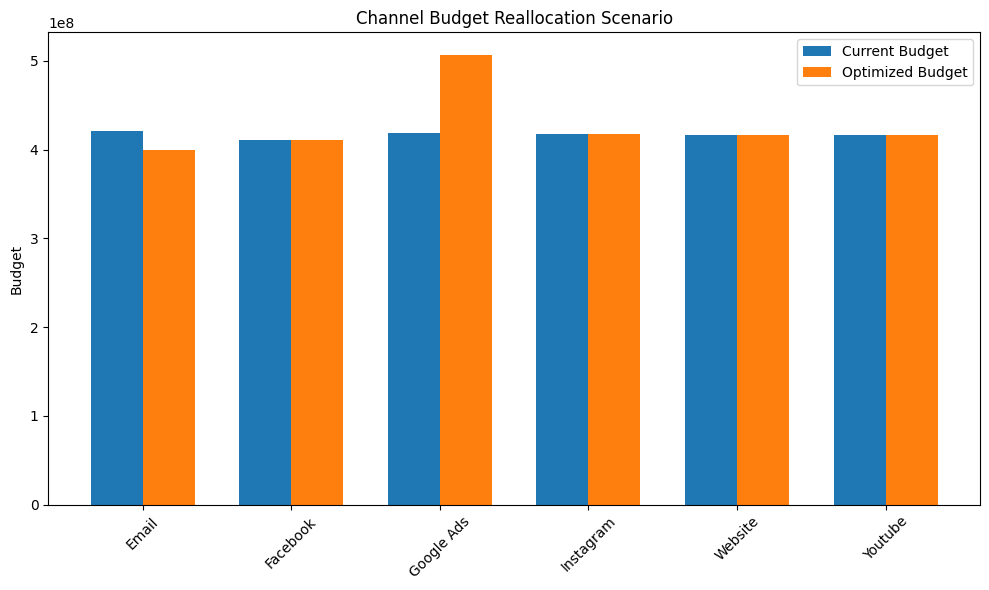

In [59]:
plt.figure(figsize=(10,6))

x = np.arange(len(channel_summary["channels_used"]))
width = 0.35

plt.bar(
    x - width/2,
    channel_summary["current_spend"],
    width,
    label="Current Budget"
)

plt.bar(
    x + width/2,
    channel_summary["optimized_spend"],
    width,
    label="Optimized Budget"
)

plt.xticks(x, channel_summary["channels_used"], rotation=45)

plt.title("Channel Budget Reallocation Scenario")
plt.ylabel("Budget")
plt.legend()

plt.tight_layout()
plt.show()

# Step 13 — Visualize Segment Reallocation

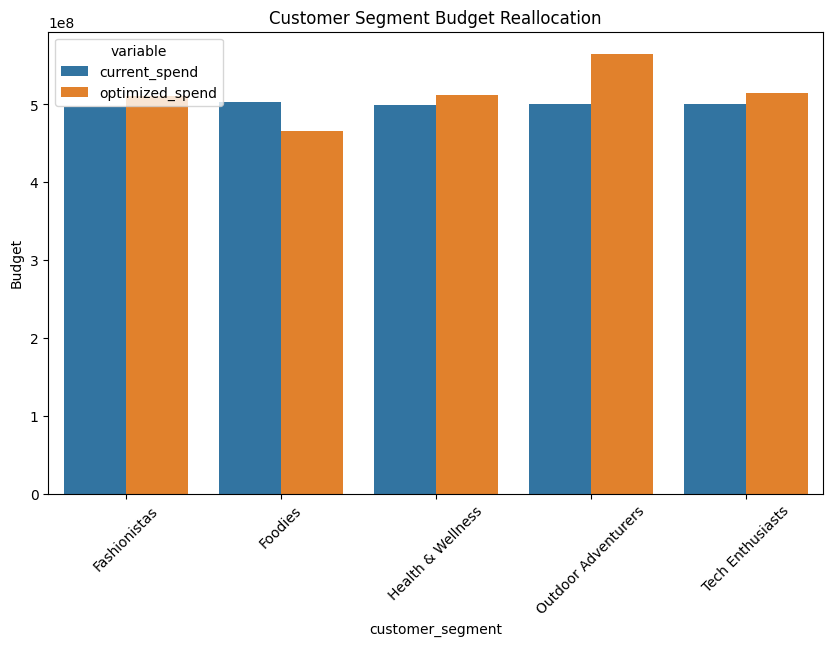

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment_summary.melt(
        id_vars="customer_segment",
        value_vars=["current_spend","optimized_spend"]
    ),
    x="customer_segment",
    y="value",
    hue="variable"
)

plt.title("Customer Segment Budget Reallocation")
plt.ylabel("Budget")
plt.xticks(rotation=45)

plt.show()

# Step 14 — Scenario Performance Summary

In [61]:
summary = pd.DataFrame({
    "Metric":[
        "Current Profit",
        "Optimized Profit",
        "Profit Improvement %"
    ],
    "Value":[
        current_profit,
        optimized_profit,
        profit_improvement
    ]
})

summary

,Metric,Value
0,Current Profit,"5,732,774,978.79"
1,Optimized Profit,"6,011,475,096.48"
2,Profit Improvement %,4.86


**📝 Marketing Budget Optimization Report**

**📌 Objective**

The objective of this analysis was to evaluate whether strategic reallocation of marketing budget across channels and customer segments could improve overall marketing profitability without significantly increasing total spend.

The analysis builds upon previous EDA, statistical testing, and regression insights, particularly:

ROI decreases as campaign spend increases (diminishing returns)

Low-budget campaigns demonstrate higher efficiency

Campaign type significantly influences ROI

Engagement metrics show weak correlation with profitability


**🔍 Approach**

A scenario-based optimization model was developed using Python to simulate targeted budget reallocations across marketing channels and customer segments.

The scenario included the following strategic adjustments:

• Email channel budget reduced by 5%
• Google Ads investment increased by 10%
• Foodies segment budget reduced by 10%
• Outdoor Adventurers segment budget increased by 10%

Using historical ROI performance, campaign revenue and profit were recalculated under the adjusted budget distribution.

This allowed estimation of potential financial impact without changing campaign performance assumptions.


**📊 Key Findings**

The optimization scenario produced the following results:

Metric	Value
Current Profit	₹5.73B
Optimized Profit	₹6.01B
Profit Improvement	4.86%


**Additional insights:**

• Budget reallocation increased overall marketing efficiency.
• High-performing channels and segments received increased investment.
• Low-efficiency segments experienced reduced spending.
• Profitability improved without a major increase in total marketing spend.


**💼 Business Impact**

The analysis demonstrates that data-driven marketing budget allocation can significantly improve profitability.


**Key implications:**

Strategic redistribution of budget toward high-performing channels and customer segments improves financial performance.

Reducing spend on lower-efficiency segments prevents wasted marketing investment.

Even moderate budget adjustments can generate measurable profit gains.

Overall, the optimized allocation scenario produced a 4.86% increase in total marketing profit, highlighting the value of analytics-driven marketing decision-making.


**🚀 Strategic Recommendation**

Organizations should adopt continuous budget optimization frameworks that:

Monitor channel and segment-level ROI

Detect diminishing returns in high-spend campaigns

Dynamically reallocate marketing investments toward high-efficiency opportunities

Implementing such optimization strategies can enable sustainable marketing growth while maintaining cost efficiency.